# Lecture 10: Language Model Fine-tuning (Generation)

**Goal**: Fine-tune a causal language model so it learns to generate a specific output given a structured prompt.

**Task**: Given a name, generate its reverse (e.g., `emma` → `amme`).

### Key Concepts
- **Causal LM fine-tuning**: update the model to produce desired text continuations
- Unlike classification, the model must *generate* tokens autoregressively
- We use a **prompt + answer** format and mask the prompt in the loss so the model only learns to predict the answer
- This is conceptually similar to instruction-tuning in modern LLMs

## Load the Dataset
- Same names dataset (~32K names) used for classification
- Each name is paired with its reverse as the target output

In [1]:
# Load one name per line from the dataset file.
data = open('names.txt').read().splitlines()

# Check dataset size.
print(f"Total names: {len(data)}")

# Preview a small sample.
data[1000:1010]


Total names: 32033


['paityn',
 'evalyn',
 'luz',
 'nathalia',
 'winnie',
 'chandler',
 'ciara',
 'danica',
 'nailah',
 'rilynn']

## Load the Pretrained Model & Tokenizer
- Same **SmolLM2-135M** base model as in the classification notebook
- Key difference: we keep the model as `AutoModelForCausalLM` (no classification head)
- The model will be fine-tuned to *generate* text, not predict a class label

In [2]:
# Import Hugging Face and PyTorch utilities.
import transformers
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# We start from a small pretrained causal language model.
model_name = "HuggingFaceTB/SmolLM2-135M"

# Load tokenizer and base LM.
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Add needed special tokens.
tokenizer.add_special_tokens({
    "pad_token": "<|pad|>",
    "bos_token": "<|startoftext|>",
})

# Resize model embeddings to match new tokenizer vocab size.
model.resize_token_embeddings(len(tokenizer))

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


/opt/miniconda3/envs/anlp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Model parameters: 134,516,160


## Baseline: Test Before Fine-Tuning
- The pretrained model has no idea what "reverse a name" means
- Outputs will be incoherent — this establishes a baseline
- After fine-tuning, the same prompts should produce correct reversals

In [ ]:
# Run baseline generations before fine-tuning.
test_names = ['emma', 'noah', 'olivia']

print("Before fine-tuning:")
print("="*50)

for name in test_names:
    # Prompt format the model should learn.
    prompt = f"<|startoftext|>Reverse the name: {name}. Answer:"
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        outputs = model.generate(
            inputs["input_ids"],
            max_new_tokens=20,
            temperature=1.0,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"{response}")


Before fine-tuning:
Reverse the name: emma. Answer: 0.4812529443310765.
Reverse the name: noah. Answer: it is only a person of that name
000B. Boole, 1
Reverse the name: olivia. Answer: a. The person is named Olivia. b. The person is named Olivia. c.


## Create Dataset

**Training format**: `<|startoftext|>Reverse the name: emma. Answer: amme<|endoftext|>`

### Important Design Decisions
- The full sequence contains **both** the prompt and the answer
- We **mask the prompt tokens** in labels (set to `-100`) so the model is only trained to predict the answer portion
- This prevents the model from wasting capacity learning to reproduce the fixed prompt template
- `-100` is PyTorch’s default ignore index for `CrossEntropyLoss`

In [ ]:
from torch.utils.data import Dataset, DataLoader
import random

class NameReversalDataset(Dataset):
    def __init__(self, names, tokenizer, max_length=64):
        self.names = names
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        reversed_name = name[::-1]

        # full_text includes both prompt and correct answer.
        full_text = f"{self.tokenizer.bos_token}Reverse the name: {name}. Answer: {reversed_name}{self.tokenizer.eos_token}"

        # prompt part will be masked in labels so model is trained to predict only answer tokens.
        prompt = f"{self.tokenizer.bos_token}Reverse the name: {name}. Answer:"

        return {
            'full_text': full_text,
            'prompt': prompt,
            'name': name,
            'reversed': reversed_name
        }

    def collate_fn(self, batch):
        full_texts = [item['full_text'] for item in batch]
        prompts = [item['prompt'] for item in batch]

        # Tokenize and pad as a batch.
        tokenized = self.tokenizer(
            full_texts,
            truncation=True,
            padding=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        labels = tokenized['input_ids'].clone()

        # Mask prompt tokens with -100 so they do not contribute to loss.
        for i, prompt in enumerate(prompts):
            prompt_tokens = self.tokenizer(prompt, add_special_tokens=False)['input_ids']
            prompt_len = len(prompt_tokens)
            labels[i, :prompt_len] = -100

        return {
            'input_ids': tokenized['input_ids'],
            'attention_mask': tokenized['attention_mask'],
            'labels': labels
        }

# Shuffle and split into train/dev/test.
random.seed(123)
random.shuffle(data)

n1 = int(0.8 * len(data))
n2 = int(0.9 * len(data))

train_data = data[:n1]
dev_data = data[n1:n2]
test_data = data[n2:]

print(f"Train: {len(train_data)}, Dev: {len(dev_data)}, Test: {len(test_data)}")

# Create Dataset objects.
train_dataset = NameReversalDataset(train_data, tokenizer)
dev_dataset = NameReversalDataset(dev_data, tokenizer)
test_dataset = NameReversalDataset(test_data, tokenizer)

# Create DataLoaders for mini-batch processing.
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=train_dataset.collate_fn)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False, collate_fn=dev_dataset.collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=test_dataset.collate_fn)


## Examine a Batch
- Sanity check: verify tensor shapes and decoded content
- Confirm that prompt tokens are masked (`-100`) and only answer tokens remain in labels

In [5]:
# Inspect one batch to understand tensor dimensions.
sample_batch = next(iter(train_loader))
print("Sample batch shape:")
print(f"  input_ids: {sample_batch['input_ids'].shape}")
print(f"  attention_mask: {sample_batch['attention_mask'].shape}")
print(f"  labels: {sample_batch['labels'].shape}")

# Decode first training input for readability.
print("
First example:")
input_text = tokenizer.decode(sample_batch['input_ids'][0], skip_special_tokens=True)
print(f"Input: {input_text}")

# Show answer tokens that remain after masking prompt with -100.
label_tokens = sample_batch['labels'][0]
valid_label_indices = (label_tokens != -100).nonzero(as_tuple=True)[0]
if len(valid_label_indices) > 0:
    valid_labels = label_tokens[valid_label_indices]
    label_text = tokenizer.decode(valid_labels, skip_special_tokens=True)
    print(f"Target (answer only): {label_text}")


Sample batch shape:
  input_ids: torch.Size([16, 18])
  attention_mask: torch.Size([16, 18])
  labels: torch.Size([16, 18])

First example:
Input: Reverse the name: giavonna. Answer: annovaig
Target (answer only):  annovaig


## Training Loop
- HuggingFace’s `AutoModelForCausalLM` computes next-token cross-entropy loss internally when `labels` are provided
- We use `AdamW` optimizer (Adam with weight decay — standard for transformer fine-tuning)
- **Gradient clipping** (`clip_grad_norm_`): prevents exploding gradients during training
- `CosineAnnealingLR` scheduler: learning rate decays smoothly over all steps
- Validation loss is monitored after each epoch to detect overfitting

In [6]:
import torch.optim as optim
from tqdm import tqdm

# Training hyperparameters.
learning_rate = 5e-5
num_epochs = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# Total optimizer steps across all epochs.
total_steps = len(train_loader) * num_epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

# Full training + validation loop.
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for batch_idx, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        # Causal LM computes next-token loss when labels are provided.
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        # Gradient clipping helps avoid unstable gradients.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Display running average training loss.
        if batch_idx % 10 == 0:
            avg_loss = total_loss / (batch_idx + 1)
            progress_bar.set_postfix({'loss': f'{avg_loss:.4f}'})

    avg_train_loss = total_loss / len(train_loader)

    # Validation (no gradients).
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in tqdm(dev_loader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_val_loss += outputs.loss.item()

    avg_val_loss = total_val_loss / len(dev_loader)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Average training loss: {avg_train_loss:.4f}")
    print(f"  Average validation loss: {avg_val_loss:.4f}")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Validation: 100%|██████████| 201/201 [00:24<00:00,  8.14it/s]


Epoch 1/3
  Average training loss: 0.8217
  Average validation loss: 0.3174


Validation: 100%|██████████| 201/201 [00:24<00:00,  8.18it/s]


Epoch 2/3
  Average training loss: 0.1851
  Average validation loss: 0.2409


Validation: 100%|██████████| 201/201 [00:24<00:00,  8.33it/s]

Epoch 3/3
  Average training loss: 0.0809
  Average validation loss: 0.2336


## Generate & Evaluate
- After fine-tuning, we use `model.generate()` to autoregressively produce the answer
- `temperature=0.1`: near-greedy decoding for more deterministic outputs
- We extract the answer by splitting on `"Answer:"` in the decoded text
- **Exact match accuracy**: the generated reversal must match character-for-character

In [7]:
def generate_reversal(model, tokenizer, name, device, max_new_tokens=20):
    # Build prompt in same format used during training.
    prompt = f"{tokenizer.bos_token}Reverse the name: {name}. Answer:"

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    model.eval()
    with torch.no_grad():
        outputs = model.generate(
            inputs["input_ids"],
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    # Decode generated token IDs into text.
    full_response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Return only the generated answer string.
    if "Answer:" in full_response:
        answer = full_response.split("Answer:")[1].strip()
        answer = answer.split()[0] if answer else ""
        return answer
    return ""

# Qualitative check after fine-tuning.
print("After fine-tuning:")
print("="*50)
test_names = ['emma', 'noah', 'olivia', 'liam', 'sophia', 'mason', 'isabella', 'william', 'mia', 'james']

correct = 0
for name in test_names:
    generated = generate_reversal(model, tokenizer, name, device)
    expected = name[::-1]
    is_correct = generated == expected
    correct += is_correct

    symbol = "✓" if is_correct else "✗"
    print(f"{name:10} → {generated:10} (expected: {expected:10}) {symbol}")

print(f"
Accuracy: {correct}/{len(test_names)} = {correct/len(test_names)*100:.1f}%")


After fine-tuning:
emma       → amme       (expected: amme      ) ✓
noah       → haon       (expected: haon      ) ✓
olivia     → aivilo     (expected: aivilo    ) ✓
liam       → mail       (expected: mail      ) ✓
sophia     → aihpos     (expected: aihpos    ) ✓
mason      → nosam      (expected: nosam     ) ✓
isabella   → allebasi   (expected: allebasi  ) ✓
william    → luottiw    (expected: mailliw   ) ✗
mia        → aim        (expected: aim       ) ✓
james      → semaj      (expected: semaj     ) ✓

Accuracy: 9/10 = 90.0%


## Evaluate on Test Set
- Compute exact-match accuracy on a sample from the held-out test set
- Error analysis: inspect which names the model gets wrong
- Common failure modes: long names, unusual character sequences

In [8]:
def evaluate_accuracy(model, tokenizer, test_names, device, sample_size=None):
    # Compute exact-match accuracy for generated reversed names.
    if sample_size:
        test_names = random.sample(test_names, min(sample_size, len(test_names)))

    correct = 0
    errors = []

    for name in tqdm(test_names, desc="Evaluating"):
        generated = generate_reversal(model, tokenizer, name, device)
        expected = name[::-1]

        if generated == expected:
            correct += 1
        else:
            errors.append((name, expected, generated))

    exact_match_acc = correct / len(test_names)

    return {
        'exact_match_accuracy': exact_match_acc,
        'errors': errors
    }

# Evaluate on a subset for faster runtime.
results = evaluate_accuracy(model, tokenizer, test_data, device, sample_size=200)

print(f"Exact Match Accuracy: {results['exact_match_accuracy']*100:.2f}%")
print(f"
Number of errors: {len(results['errors'])}/200")

# Print some mistakes for analysis.
if results['errors']:
    print("
Some examples of errors:")
    print("Name		Expected	Generated")
    print("="*45)
    for name, expected, generated in results['errors'][:10]:
        print(f"{name:12}	{expected:12}	{generated}")


Evaluating: 100%|██████████| 200/200 [00:13<00:00, 14.31it/s]

Exact Match Accuracy: 81.00%

Number of errors: 38/200

Some examples of errors:
Name		Expected	Generated
fizza       	azzif       	asirof
dayra       	aryad       	ayrad
scout       	tuocs       	kcarts
meilah      	haliem      	halime
ayaanreddy  	yddernaaya  	ydirdaanya
lejla       	aljel       	aljeel
monserratt  	ttarresnom  	ttarrsecm
jahnae      	eanhaj      	eahnaj
tsion       	noist       	noits
harmony     	ynomrah     	ytinohsm


## Analysis by Name Length
- **Hypothesis**: longer names are harder to reverse (more tokens to remember)
- We group test names by length and compute accuracy per bucket
- This reveals whether the model has learned a generalizable reversal algorithm or just memorized short patterns

Evaluating: 100%|██████████| 20/20 [00:02<00:00,  9.91it/s]


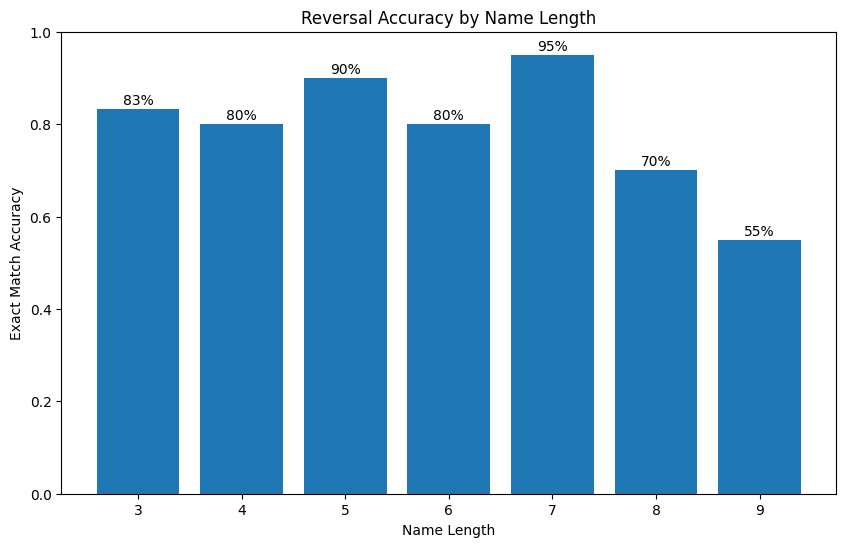

Accuracy by name length:
  Length 3: 83.3% (6 names in test set)
  Length 4: 80.0% (41 names in test set)
  Length 5: 90.0% (112 names in test set)
  Length 6: 80.0% (147 names in test set)
  Length 7: 95.0% (124 names in test set)
  Length 8: 70.0% (46 names in test set)
  Length 9: 55.0% (20 names in test set)


In [9]:
import matplotlib.pyplot as plt
from collections import defaultdict

# Group test names by length to inspect performance vs sequence length.
names_by_length = defaultdict(list)
for name in test_data[:500]:  # Limit samples for speed.
    names_by_length[len(name)].append(name)

# Evaluate each length bucket.
length_accuracies = {}
lengths = sorted(names_by_length.keys())

for length in lengths:
    # Use buckets with enough samples for a more stable estimate.
    if len(names_by_length[length]) >= 5:
        names_subset = names_by_length[length][:20]
        results = evaluate_accuracy(model, tokenizer, names_subset, device)
        length_accuracies[length] = results['exact_match_accuracy']

# Plot accuracy by name length.
if length_accuracies:
    plt.figure(figsize=(10, 6))
    lengths = list(length_accuracies.keys())
    accuracies = list(length_accuracies.values())

    plt.bar(lengths, accuracies)
    plt.xlabel('Name Length')
    plt.ylabel('Exact Match Accuracy')
    plt.title('Reversal Accuracy by Name Length')
    plt.ylim(0, 1.0)

    # Add percentage text above each bar.
    for i, (l, acc) in enumerate(zip(lengths, accuracies)):
        plt.text(l, acc + 0.01, f'{acc*100:.0f}%', ha='center')

    plt.show()

    # Print textual summary.
    print("Accuracy by name length:")
    for length, acc in sorted(length_accuracies.items()):
        count = len(names_by_length[length])
        print(f"  Length {length}: {acc*100:.1f}% ({count} names in test set)")


## Test with Different Prompt Formats
- The model was trained with one specific prompt template
- Does it generalize to rephrased prompts? (Usually not well!)
- This demonstrates that fine-tuned models are **sensitive to prompt format**
- **Takeaway**: for production use, prompt consistency between training and inference is critical

In [10]:
# Test whether model generalizes to prompt styles not seen in training.
test_prompts = [
    ("Reverse the name: {name}. Answer:", "Train"),
    ("Reverse: {name} =>", "Variation 1"),
    ("What is {name} backwards?", "Variation 2"),
    ("{name} reversed is:", "Variation 3"),
]

test_name = "sophia"
expected = test_name[::-1]

print(f"Testing different prompts for '{test_name}' (expected: {expected})")
print("="*60)

for prompt_template, prompt_type in test_prompts:
    prompt = tokenizer.bos_token + prompt_template.format(name=test_name)

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    model.eval()
    with torch.no_grad():
        outputs = model.generate(
            inputs["input_ids"],
            max_new_tokens=20,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Simple extraction heuristic: take first token after the prompt text.
    answer = response[len(prompt_template.format(name=test_name)):].strip().split()[0] if len(response) > len(prompt_template.format(name=test_name)) else ""

    is_correct = answer == expected
    symbol = "✓" if is_correct else "✗"

    print(f"{prompt_type:10}:")
    print(f"  Prompt: {prompt_template.format(name=test_name)[:40]}...")
    print(f"  Output: {answer:10} {symbol}")


Testing different prompts for 'sophia' (expected: aihpos)
Train     :
  Prompt: Reverse the name: sophia. Answer:...
  Output: aihpos     ✓
Variation 1:
  Prompt: Reverse: sophia =>...
  Output: aihpos     ✓
Variation 2:
  Prompt: What is sophia backwards?...
  Output:            ✗
Variation 3:
  Prompt: sophia reversed is:...
  Output: aihsopi    ✗
